In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. I reviewed the list of .json files available at wikipedia-movie-data and opened one of the files containing a year in its name to examine its structure. After that, I formed a sequence of dataset file names to download using numpy.arange. The sequence included at least five datasets (for example, from 1960 to 2000 inclusive). I then generated the full file addresses by concatenating the base URL with the year values.

In [ ]:
indexes= np.arange(1950,1991,10)
json_files= [f'movies-{i}s.json' for i in indexes]
json_dir= 'https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/'
dataframes=[]

2. I iterated through all the selected .json files and read each one as a JSON object. I removed unnecessary columns such as ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']. Then, I kept only the complete rows without missing values. Finally, I combined the information from all the files into a single consolidated dataset.

In [ ]:
for file in json_files:
    file_path = json_dir + file
    try:
        df = pd.read_json(file_path)
    except Exception as e:
        print(f'Could not read {file_path}: {e}')
        continue

    drop_cols = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']
    df = df.drop(columns=drop_cols, errors='ignore')
    df = df.dropna()
    dataframes.append(df)

combined = pd.concat(dataframes, ignore_index=True)

3. I checked the size of the final dataset, ensuring that it included exactly four columns. The number of rows depended on the number of files selected. To safeguard against any unexpected issues, I saved a copy of the dataset in both CSV and JSON formats.

In [ ]:
combined.to_csv('movies_combined.csv', index=False)
print('Shape: ',combined.shape)
df=combined

Shape:  (11471, 4)


4. I did not use the describe method for the JSON file since it contained nested structures. Instead, I checked the content of the first few rows and applied the info method to better understand the dataset’s structure and data types.

In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11471 entries, 0 to 11470
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   11471 non-null  object
 1   year    11471 non-null  int64 
 2   cast    11471 non-null  object
 3   genres  11471 non-null  object
dtypes: int64(1), object(3)
memory usage: 358.6+ KB


In [ ]:
combined.head(10)

,title,year,cast,genres
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]","[Crime, Drama, Noir]"
1,Abbott and Costello in the Foreign Legion,1950,"[Abbott and Costello, Patricia Medina]",[Comedy]
2,Across the Badlands,1950,"[Charles Starrett, Smiley Burnette]",[Western]
3,The Admiral Was a Lady,1950,"[Edmond O'Brien, Wanda Hendrix, Steve Brodie]",[Comedy]
4,All About Eve,1950,"[Bette Davis, Anne Baxter, Gary Merrill, Celes...",[Drama]
5,Ambush,1950,"[Robert Taylor, John Hodiak, Arlene Dahl]",[Western]
6,American Guerrilla in the Philippines,1950,"[Tyrone Power, Micheline Presle]",[War]
7,Annie Get Your Gun,1950,"[Betty Hutton, Howard Keel]","[Musical, Comedy]"
8,The Arizona Cowboy,1950,"[Rex Allen, Teala Loring]",[Western]
9,Arizona Territory,1950,"[Whip Wilson, Andy Clyde, Nancy Saunders]",[Western]


5. I worked with the movie genres by identifying the top 10 genres based on the number of films. I then created both a bar chart and a pie chart to visualize the distribution. In addition, I displayed a summary table on the screen to present the aggregated results clearly.

In [ ]:
df_exploded= df.explode('genres')
df_exploded=df_exploded[df_exploded['genres'].notna()]
df_exploded

,title,year,cast,genres
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]",Crime
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]",Drama
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]",Noir
1,Abbott and Costello in the Foreign Legion,1950,"[Abbott and Costello, Patricia Medina]",Comedy
2,Across the Badlands,1950,"[Charles Starrett, Smiley Burnette]",Western
...,...,...,...,...
11469,The Wood,1999,"[Omar Epps, Richard T. Jones, Taye Diggs]",Comedy
11469,The Wood,1999,"[Omar Epps, Richard T. Jones, Taye Diggs]",Drama
11470,The World Is Not Enough,1999,"[Pierce Brosnan, Sophie Marceau, Robert Carlyl...",Spy
11470,The World Is Not Enough,1999,"[Pierce Brosnan, Sophie Marceau, Robert Carlyl...",Action


In [ ]:
genres_counts=df_exploded['genres'].value_counts().reset_index()
genres_counts.columns=['genre','movie_counts']

print('\nTop 10 genres: ')
print(genres_counts.head(10))


Top 10 genres: 
             genre  movie_counts
0            Drama          3748
1           Comedy          3310
2          Western          1250
3            Crime          1042
4           Action           961
5           Horror           929
6         Thriller           925
7          Romance           828
8        Adventure           741
9  Science Fiction           722


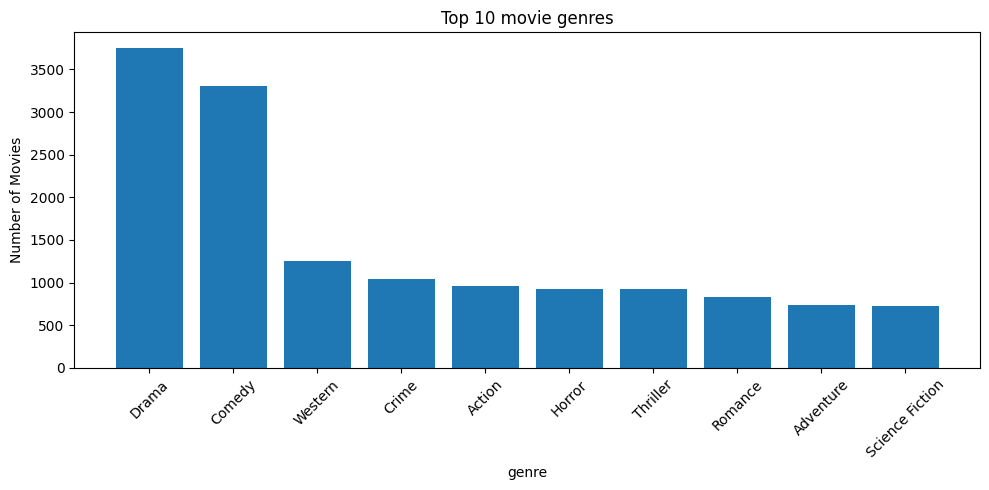

In [ ]:
top10=genres_counts.head(10)
plt.figure(figsize=(10,5))
plt.bar(top10['genre'],top10['movie_counts'])
plt.xticks(rotation=45)
plt.title('Top 10 movie genres')
plt.xlabel('genre')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

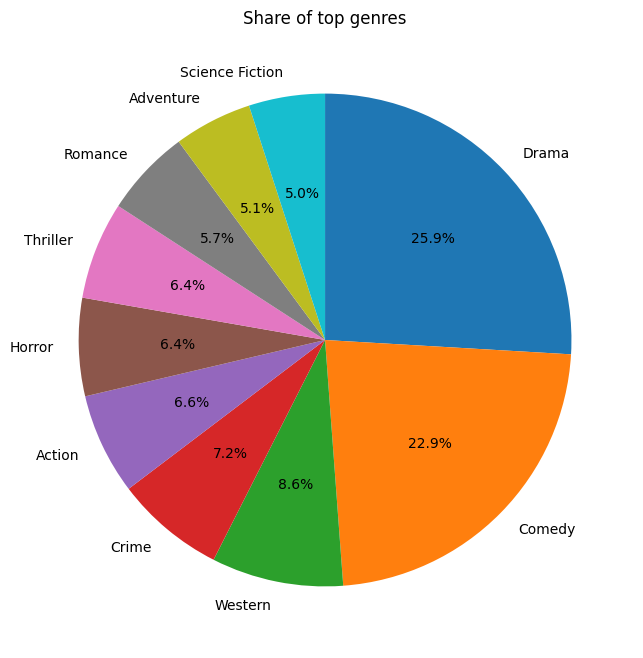

In [ ]:
plt.figure(figsize=(10,8))
plt.pie(
    genres_counts['movie_counts'].head(10),
    labels=genres_counts['genre'].head(10),
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Share of top genres')
plt.show()

6. I selected the three most popular genres and analyzed how their popularity changed over the chosen time period. For this, I calculated the number of films in each genre for every year in the dataset. Finally, I visualized the results with a line chart to clearly show the trends over time.

In [ ]:
top3= ['Drama','Comedy','Western']

for g in top3:
  df[g]=df['genres'].apply(lambda x:1 if g in x else 0)
df.head()

,title,year,cast,genres,Drama,Comedy,Western
0,711 Ocean Drive,1950,"[Edmond O'Brien, Joanne Dru, Dorothy Patrick]","[Crime, Drama, Noir]",1,0,0
1,Abbott and Costello in the Foreign Legion,1950,"[Abbott and Costello, Patricia Medina]",[Comedy],0,1,0
2,Across the Badlands,1950,"[Charles Starrett, Smiley Burnette]",[Western],0,0,1
3,The Admiral Was a Lady,1950,"[Edmond O'Brien, Wanda Hendrix, Steve Brodie]",[Comedy],0,1,0
4,All About Eve,1950,"[Bette Davis, Anne Baxter, Gary Merrill, Celes...",[Drama],1,0,0


In [ ]:
trend=df.groupby('year')[top3].sum().reset_index()
print(trend.head())

   year  Drama  Comedy  Western
0  1950     79      82      130
1  1951     92      85      108
2  1952     83      78      105
3  1953     88      58       85
4  1954     63      28       66


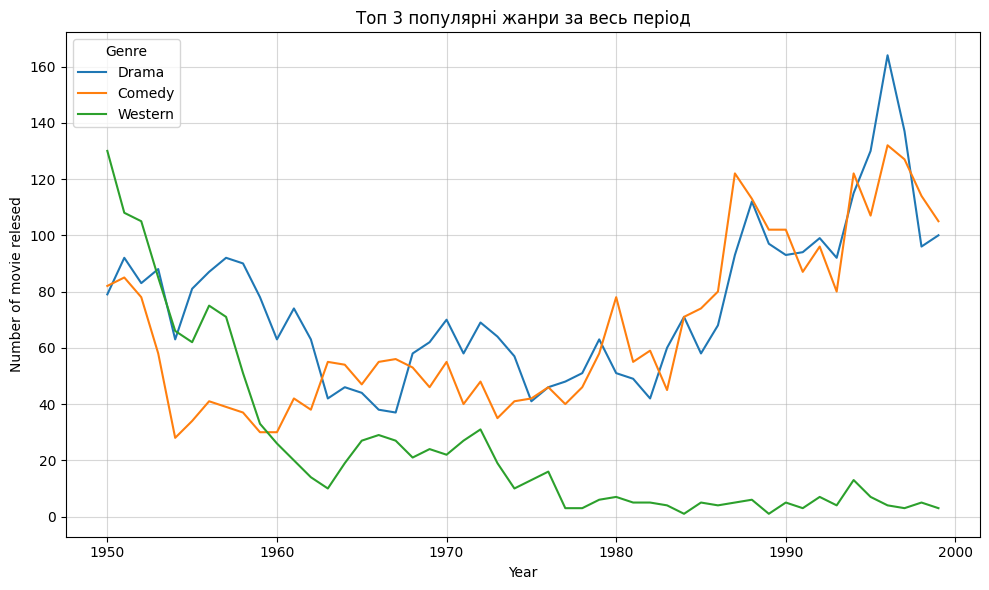

In [ ]:
plt.figure(figsize=(10,6))
for g in top3:
  plt.plot(trend['year'],trend[g],label=g)

plt.title("Топ 3 популярні жанри за весь період")
plt.xlabel('Year')
plt.ylabel('Number of movie relesed')
plt.legend(title='Genre')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

7. I worked with the actors by identifying the top 10 based on the number of films they appeared in. I then created either a bar chart or a pie chart to visualize the distribution. In addition, I displayed a summary table on the screen to present the aggregated results clearly.

             actor  movie_counts
0     Gene Hackman            63
1   Robert Mitchum            62
2  Charles Bronson            59
3   Walter Matthau            58
4     Kirk Douglas            57
5       Glenn Ford            56
6  Charlton Heston            55
7      Tony Curtis            55
8   Burt Lancaster            55
9    Robert Duvall            55


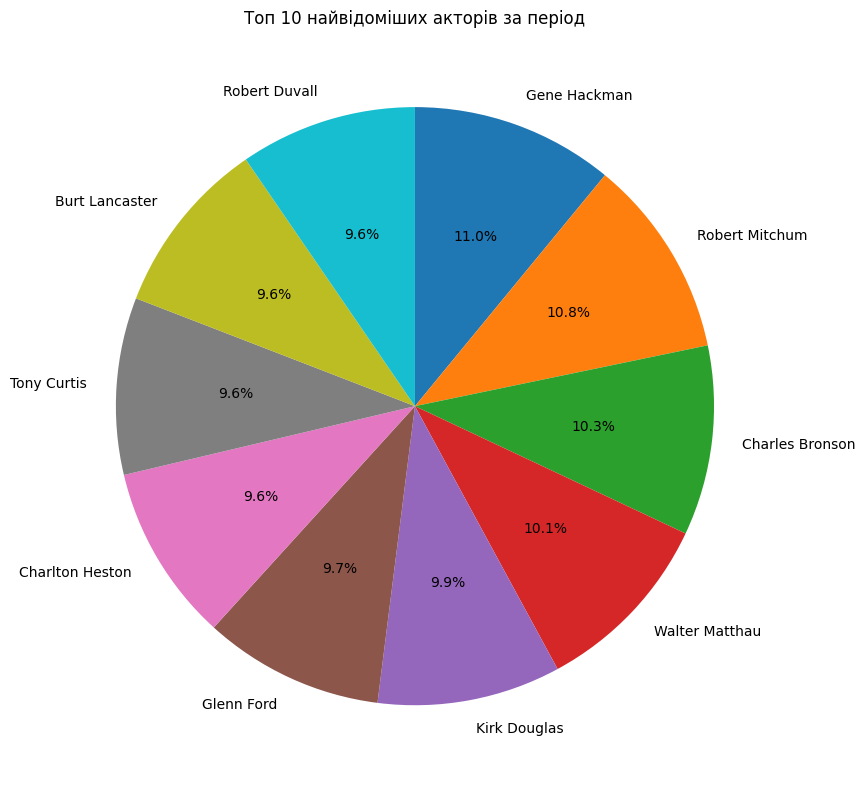

In [ ]:
all_actors=[actor for sublist in df['cast'] for actor in sublist]

actor_counts=pd.Series(all_actors).value_counts().reset_index()
actor_counts.columns=['actor', 'movie_counts']

top10_act=actor_counts.head(10)

print(top10_act)

plt.figure(figsize=(10,8))
plt.pie(
    top10_act['movie_counts'],
    labels=top10_act['actor'],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
)
plt.title('Топ 10 найвідоміших акторів за період')
plt.tight_layout()
plt.show()

8. I selected the three most popular actors and analyzed how their popularity changed over the chosen time period. For this, I calculated the number of films for each actor in every year of observation. Finally, I visualized the results with a line chart to clearly show the trends over time.

<Figure size 2000x1000 with 0 Axes>

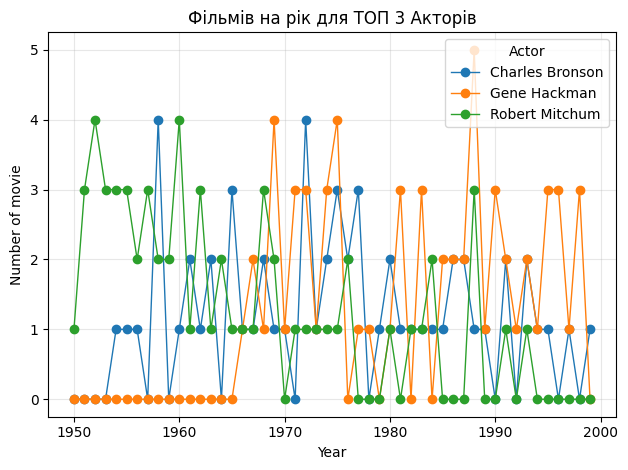

In [ ]:
top3_act=['Gene Hackman','Robert Mitchum','Charles Bronson']

df_top=df[df['cast'].apply(lambda x:any(actor in x for actor in top3_act))]

rows=[]
for _, row in df_top.iterrows():
  for actor in row['cast']:
    if actor in top3_act:
      rows.append({'year':row['year'],'actor':actor})

actors_df=pd.DataFrame(rows)

actor_year_stats=(
    actors_df.groupby(['actor','year'])
    .size()
    .reset_index(name='movie_counts')
    .sort_values(by='year')
)

pivot_df=actor_year_stats.pivot(index='year',columns='actor', values='movie_counts').fillna(0)


plt.figure(figsize=(20,10))
pivot_df.plot(kind='line',marker='o',linewidth=1)
plt.title('Фільмів на рік для ТОП 3 Акторів')
plt.xlabel('Year')
plt.ylabel('Number of movie')
plt.legend(title='Actor')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
